<a href="https://colab.research.google.com/github/pranjaldwivedii001-commits/Ad_Click_Prdiction_project/blob/main/Ad_Click_prediction_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview
## This project aims to predict whether a user will click on an advertisement based on various user and ad-related features. The goal is to build a robust classification model that can assist in optimizing ad placement and targeting strategies. We explore several machine learning models and evaluate their performance to identify the most effective solution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## DATA COLLECTION

In [2]:
df = pd.read_csv('/content/advertising.csv')

In [3]:
df.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


## DATA CLEANING:

In [4]:
df.shape

(1000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [6]:
df.isnull().sum().sum()

np.int64(0)

-- THERE IS NO NULL VALUES

In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month
df[['Timestamp', 'Hour', 'Day_of_Week', 'Month']].head()

,Timestamp,Hour,Day_of_Week,Month
0,2016-03-27 00:53:11,0,6,3
1,2016-04-04 01:39:02,1,0,4
2,2016-03-13 20:35:42,20,6,3
3,2016-01-10 02:31:19,2,6,1
4,2016-06-03 03:36:18,3,4,6


In [8]:
col = list(df.columns)
col

['Daily Time Spent on Site',
 'Age',
 'Area Income',
 'Daily Internet Usage',
 'Ad Topic Line',
 'City',
 'Male',
 'Country',
 'Timestamp',
 'Clicked on Ad',
 'Hour',
 'Day_of_Week',
 'Month']

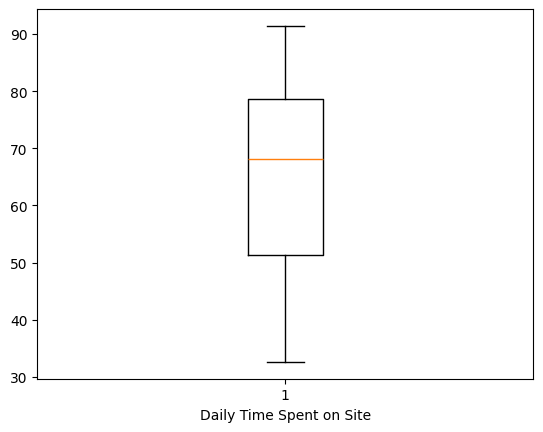

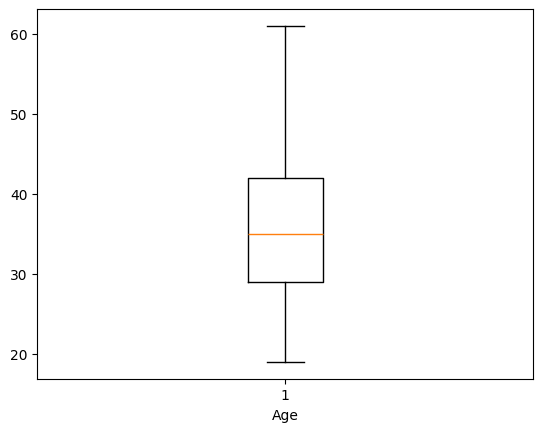

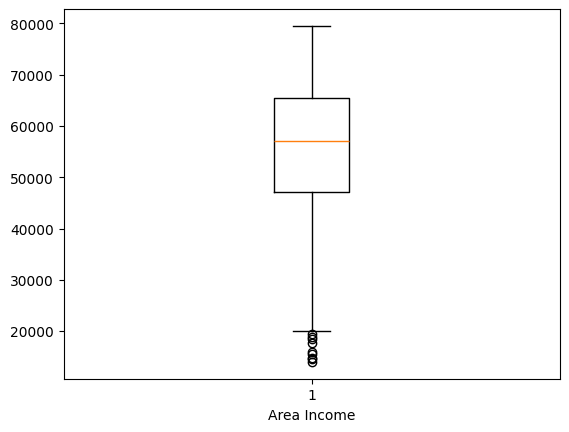

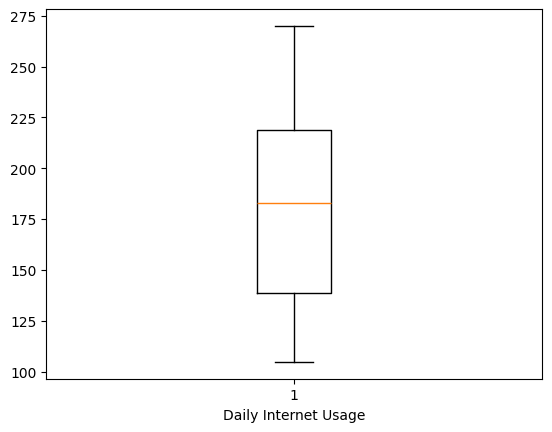

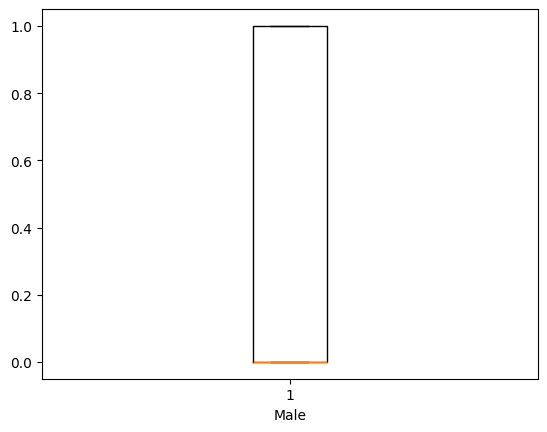

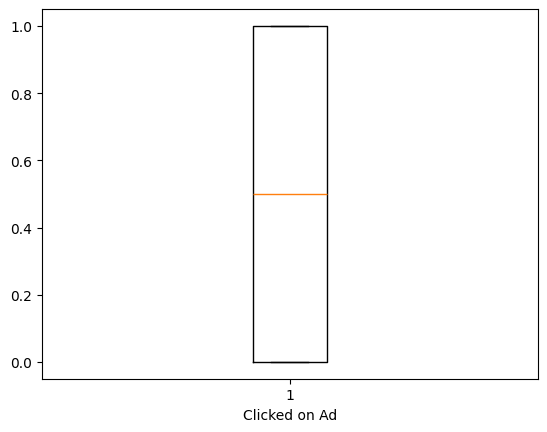

In [9]:
for c in col:
  if (df[c].dtype in ['float64','int64']):
    plt.boxplot(df[c])
    plt.xlabel(c)
    plt.show()

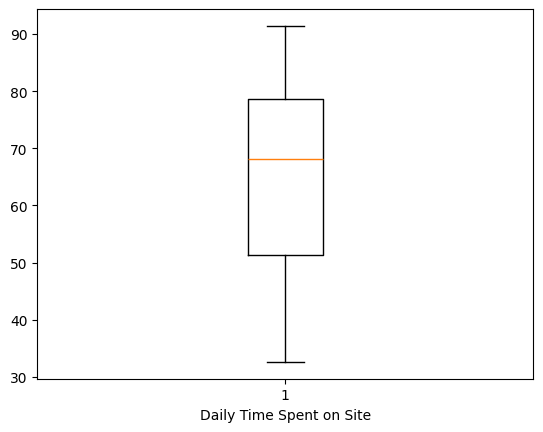

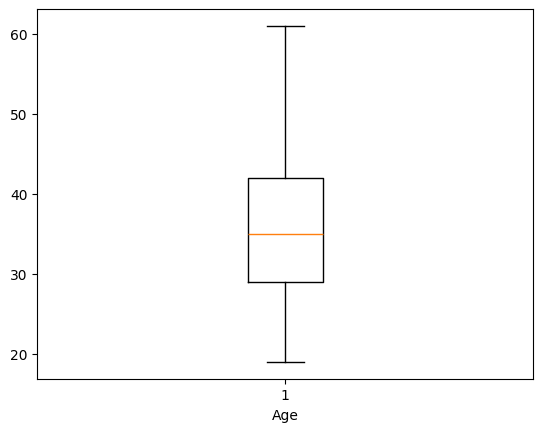

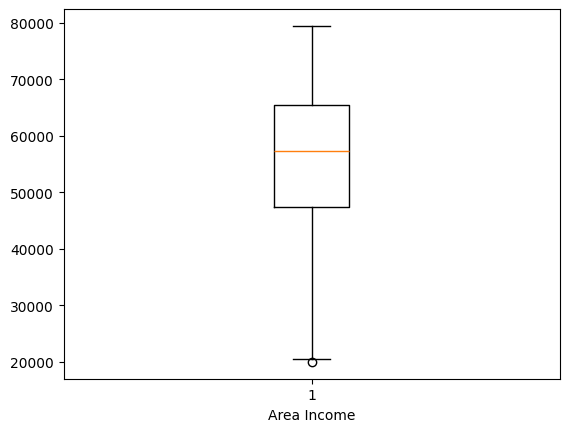

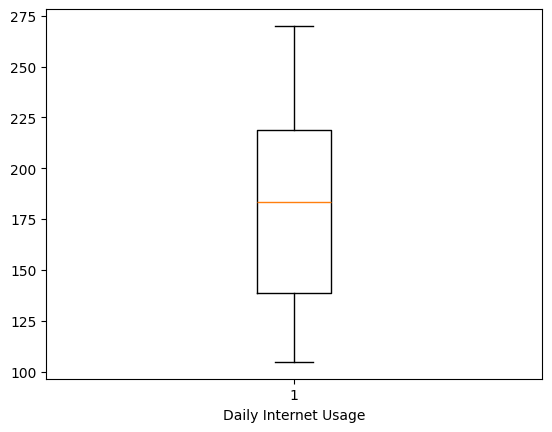

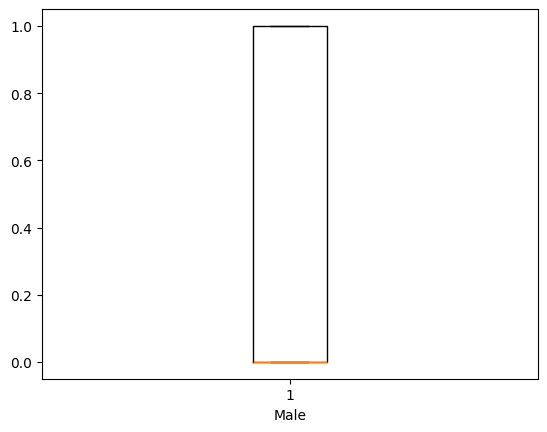

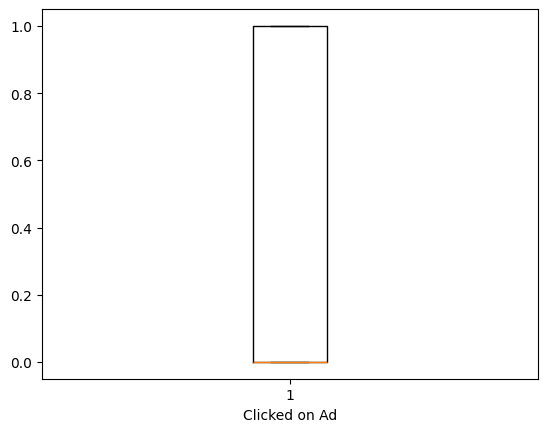

In [10]:
for c in col:
  if (df[c].dtype in ['float64', 'int64']):
    q1= df[c].quantile(0.25)
    q3= df[c].quantile(0.75)
    IQR=q3-q1

    LF=q1-(1.5*IQR)
    UF=q3+(1.5*IQR)
    df = df[(df[c]>=LF) & (df[c]<=UF)]
    plt.boxplot(df[c])
    plt.xlabel(c)
    plt.show()

 -- OUTLIERS HAS BEEN HANDLED,
 NOW OUR DATA HAVE CATEGORICAL COLUMNS WHICH CAN'T BE ENCODED AS IT WILL CREATE A VERY LARGE NUMBERS OF COLUMNS SO WE WILL DROP IT AFTER FINDING CORRELATION .

In [11]:
corrmat = df.corr(numeric_only=True)
corrmat

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Hour,Day_of_Week,Month
Daily Time Spent on Site,1.000000,-0.332851,0.313452,0.520032,-0.019975,-0.749120,0.000651,0.020883,-0.009671
Age,-0.332851,1.000000,-0.181772,-0.367954,-0.024167,0.493294,-0.049071,0.014979,0.021924
Area Income,0.313452,-0.181772,1.000000,0.352213,0.011995,-0.470211,0.038306,0.016272,-0.035793
Daily Internet Usage,0.520032,-0.367954,0.352213,1.000000,0.027740,-0.791344,0.073183,0.011906,0.018480
Male,-0.019975,-0.024167,0.011995,0.027740,1.000000,-0.041786,0.058077,-0.037138,0.005273
Clicked on Ad,-0.749120,0.493294,-0.470211,-0.791344,-0.041786,1.000000,-0.048663,0.001295,0.010612
Hour,0.000651,-0.049071,0.038306,0.073183,0.058077,-0.048663,1.000000,0.012068,-0.014390
Day_of_Week,0.020883,0.014979,0.016272,0.011906,-0.037138,0.001295,0.012068,1.000000,-0.020983
Month,-0.009671,0.021924,-0.035793,0.018480,0.005273,0.010612,-0.014390,-0.020983,1.000000


## VISUALIZATION:

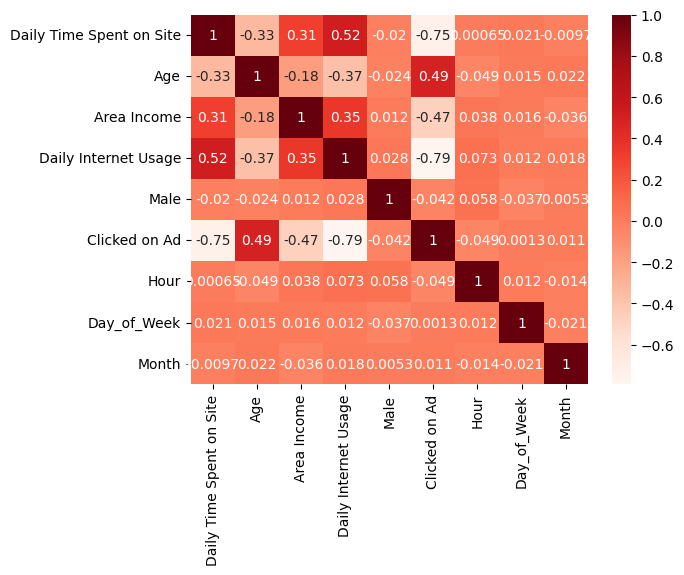

In [12]:
sns.heatmap(corrmat, annot=True , cmap= 'Reds')
plt.show()

INSIGHTS-
-- Daily Internet Usage (-0.79): There is a strong negative correlation between 'Daily Internet Usage' and 'Clicked on Ad'.

-- Daily Time Spent on Site (-0.75): Similarly, there is a strong negative correlation between 'Daily Time Spent on Site' and 'Clicked on Ad'.

-- Area Income (-0.48): There is a moderate negative correlation between 'Area Income' and 'Clicked on Ad'.

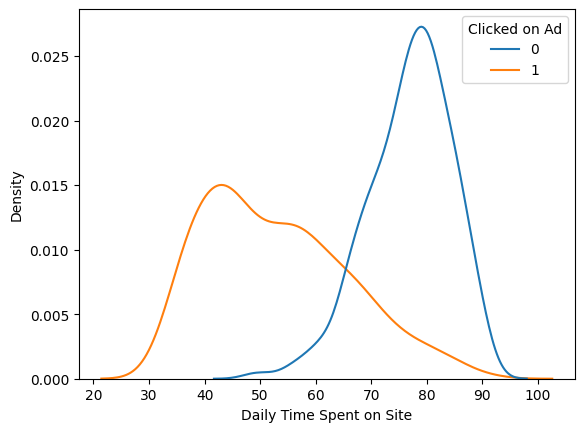

In [13]:
sns.kdeplot(data= df, x='Daily Time Spent on Site',hue='Clicked on Ad')
plt.show()

## MOST THE "DAILY TIME SPENT ON SITE" LESS THE "CLICKED ON AD"

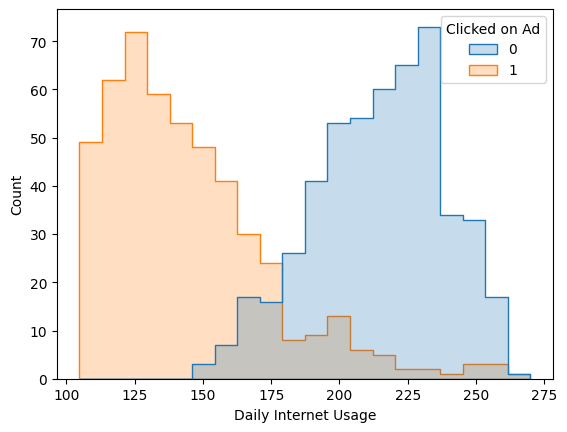

In [14]:
sns.histplot(data=df, x='Daily Internet Usage',hue='Clicked on Ad',element='step', bins=20)
plt.show()

## HIGHER THE "DAILY INTERNET USAGE" LOWER THE "Clicked on Ad"

In [15]:
df.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Hour,Day_of_Week,Month
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,0,6,3
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,1,0,4
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,20,6,3
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,2,6,1
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,3,4,6


In [16]:
df['City'].value_counts()

,count
City,
Lisamouth,3
Williamsport,3
West Amanda,2
Johnstad,2
Shelbyport,2
...,...
Burgessside,1
Hurleyborough,1
Garychester,1


In [17]:
categorical_cols = ['Ad Topic Line', 'City', 'Country', 'Timestamp']
df_cleaned = df.drop(columns = categorical_cols)
df2 = df_cleaned
df2.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Hour,Day_of_Week,Month
0,68.95,35,61833.90,256.09,0,0,0,6,3
1,80.23,31,68441.85,193.77,1,0,1,0,4
2,69.47,26,59785.94,236.50,0,0,20,6,3
3,74.15,29,54806.18,245.89,1,0,2,6,1
4,68.37,35,73889.99,225.58,0,0,3,4,6


## NOW WE HAVE NEW DATA IN WHICH ALL HIGH CARDINALITY COLUMNS AND ALL THE COLUMNS ARE IN NUMERIC SO WE CAN NOW TRAIN AND SPLIT THE DATA.

In [18]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 991 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  991 non-null    float64
 1   Age                       991 non-null    int64  
 2   Area Income               991 non-null    float64
 3   Daily Internet Usage      991 non-null    float64
 4   Male                      991 non-null    int64  
 5   Clicked on Ad             991 non-null    int64  
 6   Hour                      991 non-null    int32  
 7   Day_of_Week               991 non-null    int32  
 8   Month                     991 non-null    int32  
dtypes: float64(3), int32(3), int64(3)
memory usage: 65.8 KB


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
X = df2.drop('Clicked on Ad',axis=1)
y = df2['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((792, 8), (199, 8), (792,), (199,))

## Logistic Regression :

In [21]:
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())

])
log_pipe.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [22]:
y_pred_log = log_pipe.predict(X_test)

In [23]:
accuracy_score(y_pred_log,y_test)

0.9748743718592965

In [42]:
print(f'Confusion matrix is : {confusion_matrix(y_test, y_pred_log)}')

Confusion matrix is : [[101   2]
 [  3  93]]


## Decision Tree Model :

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', DecisionTreeClassifier(random_state=42))])

In [26]:
y_pred_dt = dt_pipe.predict(X_test)

In [27]:
print(f'Decision Tree Model Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_dt)}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_dt)}')


Decision Tree Model Accuracy: 0.9648

Confusion Matrix:
[[101   2]
 [  5  91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       103
           1       0.98      0.95      0.96        96

    accuracy                           0.96       199
   macro avg       0.97      0.96      0.96       199
weighted avg       0.97      0.96      0.96       199



## Random Forest Model :

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

In [29]:
y_pred_rf = rf_pipe.predict(X_test)

In [30]:
print(f'Random Forest Model Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_rf)}')


Random Forest Model Accuracy: 0.9749

Confusion Matrix:
[[101   2]
 [  3  93]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       103
           1       0.98      0.97      0.97        96

    accuracy                           0.97       199
   macro avg       0.98      0.97      0.97       199
weighted avg       0.97      0.97      0.97       199



## K-Nearest Neighbors (KNN) Model :

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [32]:
y_pred_knn = knn_pipe.predict(X_test)

In [33]:
print(f'KNN Model Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_knn)}')


KNN Model Accuracy: 0.9598

Confusion Matrix:
[[102   1]
 [  7  89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       103
           1       0.99      0.93      0.96        96

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



## Support Vector Machine (SVM) Model :

In [34]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42))
])

svm_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(random_state=42))])

In [35]:
y_pred_svm = svm_pipe.predict(X_test)

In [36]:
print(f'SVM Model Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_svm)}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_svm)}')


SVM Model Accuracy: 0.9698

Confusion Matrix:
[[100   3]
 [  3  93]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       103
           1       0.97      0.97      0.97        96

    accuracy                           0.97       199
   macro avg       0.97      0.97      0.97       199
weighted avg       0.97      0.97      0.97       199



## Comparison Between Model :

In [37]:
print(f'Logistic Regression Model Accuracy: {accuracy_score(y_test, y_pred_log):.4f}')

print(f'\nDecision Tree Model Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')

print(f'\nRandom Forest Model Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

print(f'\nKNN Model Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')

print(f'\nSVM Model Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')


Logistic Regression Model Accuracy: 0.9749

Decision Tree Model Accuracy: 0.9648

Random Forest Model Accuracy: 0.9749

KNN Model Accuracy: 0.9598

SVM Model Accuracy: 0.9698


## Cross-Validation Example: Logistic Regression

Here, we will explicitly perform k-fold cross-validation on the Logistic Regression model to assess the stability of its performance.

In [38]:
from sklearn.model_selection import cross_val_score

log_pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

cv_scores = cross_val_score(log_pipe_cv, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation scores for Logistic Regression (5 folds): {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")


Cross-validation scores for Logistic Regression (5 folds): [0.98994975 0.95959596 0.98989899 0.95959596 0.95959596]
Mean cross-validation accuracy: 0.9717
Standard deviation of cross-validation accuracy: 0.0149


## Cheching Overfitting Or Underfitting :

In [48]:
train_pred = log_pipe.predict(X_train)
train_auc = accuracy_score(y_train,train_pred)
test_auc = accuracy_score(y_test,y_pred_log)

print(train_auc)
print(test_auc)

0.9722222222222222
0.9748743718592965


## As we can see both train and test accuracy is approx equal , so it's not overfitting nor underfitting.

# Ad Clicks Prediction Project

## Overview
This project aims to predict whether a user will click on an advertisement based on various user and ad-related features. The goal is to build a robust classification model that can assist in optimizing ad placement and targeting strategies. We explore several machine learning models and evaluate their performance to identify the most effective solution.

## Dataset
The dataset `advertising.csv` contains information about users, their internet usage, demographics, and whether they clicked on an ad. Key features include:
- `Daily Time Spent on Site`
- `Age`
- `Area Income`
- `Daily Internet Usage`
- `Ad Topic Line`
- `City`
- `Male` (binary: 0 for female, 1 for male)
- `Country`
- `Timestamp`
- `Clicked on Ad` (target variable: 0 for no click, 1 for click)

## Data Preprocessing and Feature Engineering
1.  **Missing Values**: No missing values were found in the dataset.
2.  **Timestamp Features**: The `Timestamp` column was converted to datetime objects, and new features `Hour`, `Day_of_Week`, and `Month` were extracted.
3.  **Outlier Handling**: Outliers in numerical features were identified and capped using the IQR method.
4.  **Categorical Feature Removal**: High-cardinality categorical features such as `Ad Topic Line`, `City`, `Country`, and the original `Timestamp` were dropped to simplify the model and avoid issues with one-hot encoding a large number of unique values. The remaining features were all numerical.

## Exploratory Data Analysis (EDA) - Key Insights
Correlation analysis revealed strong relationships between certain features and ad clicks:
-   **`Daily Internet Usage` (-0.79)**: Strong negative correlation. Users with higher daily internet usage are less likely to click on ads.
-   **`Daily Time Spent on Site` (-0.75)**: Strong negative correlation. Users spending more time on the site are less likely to click on ads.
-   **`Area Income` (-0.47)**: Moderate negative correlation. Higher area income is associated with a lower likelihood of clicking on ads.
-   **`Age` (0.49)**: Moderate positive correlation. Older users show a higher propensity to click on ads.
-   `Male`, `Hour`, `Day_of_Week`, and `Month` showed weaker correlations, suggesting less influence on ad click behavior compared to the other features.

## Model Development and Evaluation
We trained and evaluated five different classification models. All models were built using `scikit-learn` pipelines, incorporating `StandardScaler` for feature scaling and the respective classification algorithm.

### Models Implemented:
1.  **Logistic Regression**
2.  **Decision Tree Classifier**
3.  **Random Forest Classifier**
4.  **K-Nearest Neighbors (KNN)**
5.  **Support Vector Machine (SVM)**

### Model Performance Summary:
| Model                       | Accuracy (Test Set) |
| :-------------------------- | :------------------ |
| Logistic Regression         | 0.9749              |
| Decision Tree Classifier    | 0.9648              |
| Random Forest Classifier (Initial) | 0.9749              |
| K-Nearest Neighbors (KNN)   | 0.9598              |
| Support Vector Machine (SVM)| 0.9698              |


## Conclusion
All implemented models achieved high accuracy, consistently performing in the 96-97% range on the test set. Logistic Regression and the initial Random Forest model showed slightly superior performance. The strong predictive power of the models, combined with the insights from EDA, suggests that features like `Daily Internet Usage`, `Daily Time Spent on Site`, `Area Income`, and `Age` are crucial in determining ad click likelihood.

This project provides a solid foundation for understanding and predicting ad click behavior, which can be further leveraged for targeted advertising campaigns and improved user engagement strategies.